In [1]:
# _Day11_12_Frame_to_Frame_Distance_Calculation
# _and_Trajectory_Plotting_with_Y_axis_inversion

In [2]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 5.3 MB/s eta 0:00:00


In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image as PILImage
from ultralytics import YOLO
model = YOLO('yolov8n.pt')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
def detect_ball_yolo(image_path,conf_threshold):
  print()
  results = model.predict(image_path, conf=conf_threshold, verbose=False)
  for box in results[0].boxes:
    if int(box.cls[0]) == 32:
      print("===================")
      print("YOLO detection used")
      print("===================")
      annotated = results[0].plot()
      plt.imshow(annotated)
      plt.axis('off')
      plt.show()
      x1, y1, x2, y2 = box.xyxy[0]
      cx = float((x1 + x2) / 2)
      cy = float((y1 + y2) / 2)
      return float(box.conf[0]), (cx, cy)
  return None, None




def detect_ball(image_path, lower, upper):

 #load image
  img = cv2.imread(image_path)
  # convert to HSV
  hsv = cv2.cvtColor(img,cv2.COLOR_BGR2HSV)

  # create mask
  mask = cv2.inRange(hsv,lower,upper)

  # find contours
  contour_exter,hierarchy = cv2.findContours(
      mask,
      cv2.RETR_EXTERNAL,
      cv2.CHAIN_APPROX_SIMPLE
  )
  # filter by area + circularity
  best_ratio =0
  best_contour = None
  best_radius = None
  best_center = None
  for contour in contour_exter:
    area = cv2.contourArea(contour)
    if area > 100:
      center, radius = cv2.minEnclosingCircle(contour)
      circle_area = np.pi * radius**2
      ratio = area / circle_area
      if ratio > 0.7 and ratio > best_ratio:
        best_ratio = ratio
        best_contour = contour
        best_radius = radius
        best_center = center

  if best_center is None:
    print("HSV also failed to detect the ball")
    return None
  # print(best_ratio,best_radius)


  # draw result
  img_copy= img.copy()
  center_int = (int(best_center[0]),int(best_center[1]))
  radius_int = int(best_radius)
  cv2.circle(img_copy,center_int,radius_int,(0,255,0),4)

  # return or display the image
  plt.imshow(cv2.cvtColor(img_copy,cv2.COLOR_BGR2RGB))
  plt.show()
  return best_center, best_radius



def detect_ball_hybrid(image_path, conf_threshold=0.4):

  conf, center = detect_ball_yolo(image_path,conf_threshold)
  if conf is not None and conf>=conf_threshold:
    print("\n")
    print(f"Confidence of finding ball is : {conf}")
    return center

  else:
    print("\n")
    print("============================================================")
    print("YOLO failed or low confidence — falling back to HSV detection")
    print("============================================================")
    lower_int = np.array([0, 0, 180])
    upper_int = np.array([179, 60, 255])
    result = detect_ball(image_path, lower_int, upper_int)
    if result is None:
      print("Both YOLO and HSV failed to detect the ball")
      return None
    center_2, radius_2 = result
    print("\n")
    print(f"The best center and radius are : {center_2}, {radius_2}")
    return center_2









YOLO detection used


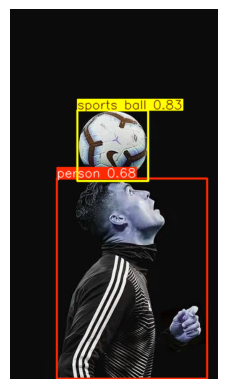



Confidence of finding ball is : 0.8320321440696716

YOLO detection used


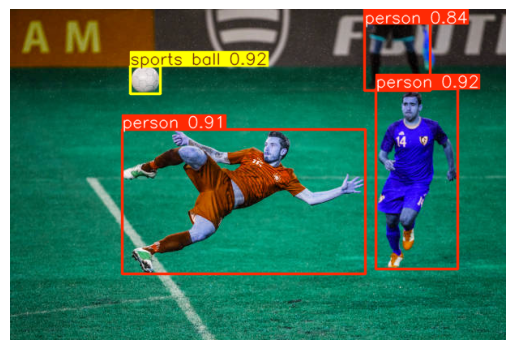



Confidence of finding ball is : 0.9248962998390198

YOLO detection used


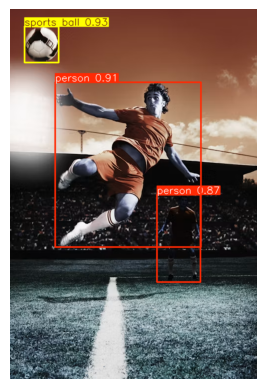



Confidence of finding ball is : 0.9265037775039673



YOLO failed or low confidence — falling back to HSV detection


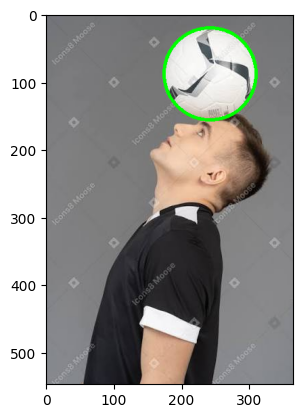



The best center and radius are : (242.7771759033203, 88.83695983886719), 68.2364273071289

YOLO detection used


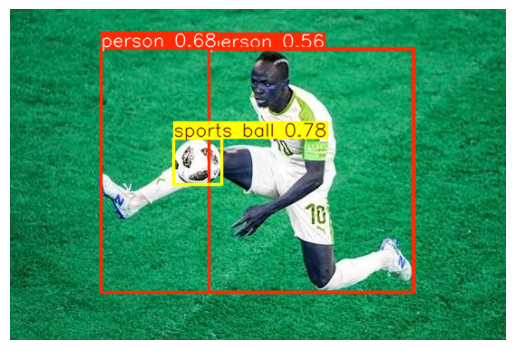



Confidence of finding ball is : 0.7753517627716064


In [6]:
# result_1 = detect_ball_hybrid("/content/sadio_ball.jpg")
centroid_history =[]
images_list = ["/content/Ronaldo_ball.jpg","/content/football image.jpg","/content/football_pic.jpg","/content/random_ball.jpg","/content/sadio_ball.jpg"]

for images in images_list:
  result_2 = detect_ball_hybrid(images)
  centroid_history.append(result_2)



In [ ]:
# Built a hybrid ball detector combining YOLOv8 (primary) with HSV color detection
#  (fallback) when YOLO's confidence is below threshold. Discovered a critical
#  edge case during testing: HSV can silently return a wrong detection
#   (matching background/clothing instead of the ball) rather than failing cleanly,
#    which is more dangerous than an outright failure since it produces
#    confident-looking bad data. Fixed by adding a circularity threshold (ratio > 0.7)
#    to reject non-ball-shaped contours, plus explicit None-checks at both the HSV and
#    hybrid levels so the system fails safely and reports "no detection" instead
#     of returning garbage coordinates.

In [7]:
print(centroid_history)

[(165.7427215576172, 220.77548217773438), (166.67709350585938, 87.29705810546875), (64.30502319335938, 72.17340850830078), (242.7771759033203, 88.83695983886719), (206.97885131835938, 167.74713134765625)]


In [18]:
distances = []
for i in range(len(centroid_history) - 1):
  x1, y1 = centroid_history[i]
  x2, y2 = centroid_history[i+1]
  result = ((x2-x1)**2 + (y2-y1)**2)**0.5
  distances.append(result)
  print(x1,y1)
  print(x2,y2)

# max_jump = max(distances)
# index_max_jump = distances.index(max_jump)
# print(f"Largest jump: {max_jump} between frame {index_max_jump} and frame {index_max_jump+1}")
# print(distances)

165.7427215576172 220.77548217773438
166.67709350585938 87.29705810546875
166.67709350585938 87.29705810546875
64.30502319335938 72.17340850830078
64.30502319335938 72.17340850830078
242.7771759033203 88.83695983886719
242.7771759033203 88.83695983886719
206.97885131835938 167.74713134765625


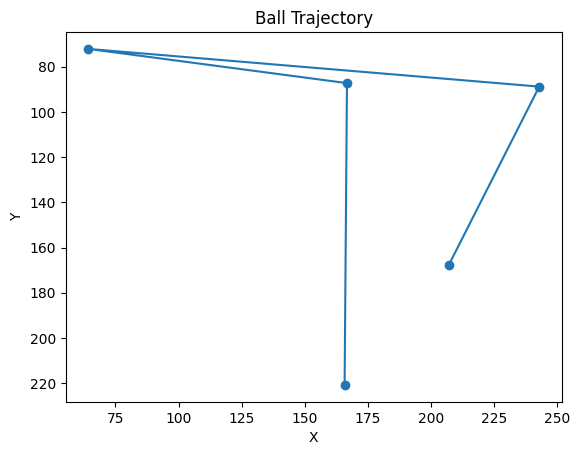

In [21]:
# Day 12: Trajectory Visualization — plotting the ball's path on
#a graph instead of just staring at numbers.

# Steps:

# Extract all x-values and y-values from centroid_history into two separate lists
# Plot them using matplotlib.pyplot.plot(), connecting the points with lines
# Mark the start and end points differently so you can see direction of movement
# Flip the y-axis if needed — image coordinates have y increasing downward, opposite of normal graphs

x_list = []
y_list = []

for x,y in centroid_history:
  x_list.append(x)
  y_list.append(y)


plt.plot(x_list, y_list, marker='o')
plt.gca().invert_yaxis()
plt.title("Ball Trajectory")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()



